# Quantum Reachability Analysis - Quickstart

This notebook demonstrates the class-based API for quantum reachability analysis.

**Three criteria tested:**
- **Moment**: Tests positive definiteness of moment matrix (fast, no optimization)
- **Spectral**: Maximizes spectral overlap via L-BFGS-B
- **Krylov**: Maximizes Krylov subspace projection via L-BFGS-B (Lanczos iteration)

**Estimated runtime:** ~10-15 minutes

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
from src.models import CanonicalQuditModel, QubitGridModel
from src.criteria import SpectralCriterion, KrylovCriterion, MomentCriterion, Verdict
from src.sampling import DensitySweep, SweepConfig, adaptive_K_values

## Single Reachability Test (~10 seconds)

Test whether a random target state is reachable from |0⟩ using K=10 canonical operators.

In [2]:
model = CanonicalQuditModel(dim=8, seed=42)
submodel = model.sample_submodel(10)
phi = submodel.init_state()
psi = submodel.random_state()

print(f"Model: d={model.dim}, full basis L={model.K}, submodel K={submodel.K}")
print(f"rho = K/d^2 = {submodel.K / model.dim**2:.4f}")
print()

for Criterion in [MomentCriterion, SpectralCriterion, KrylovCriterion]:
    crit = Criterion(submodel, phi, psi, tau=0.99)
    result = crit.is_reachable(maxiter=100, restarts=3)
    print(f"  {Criterion.__name__:20s}: {result.verdict.value}, score={result.score:.4f}")

Model: d=8, full basis L=64, submodel K=10
rho = K/d^2 = 0.1562

  MomentCriterion     : inconclusive, score=0.0000
  SpectralCriterion   : unreachable, score=0.5821


  KrylovCriterion     : unreachable, score=0.5278


## Density Sweep: CanonicalQuditModel (~12-15 min)

Sweep over K values at d=8, 16, 32 to see phase transitions.
K values are chosen to sample comparable rho = K/d^2 ranges across dimensions.

**Note on Moment criterion:** Unlike Spectral and Krylov (which maximize over lambda and are
guaranteed monotonic in K), the Moment criterion tests a *sufficient condition* for unreachability
(positive definiteness of Q + gamma*LL^T). Adding operators changes the structure of Q and L,
so P(unreachable) measured by Moment is **not guaranteed to be monotonically decreasing** in K.
Small fluctuations in the Moment curve are expected behavior, not noise.

In [3]:
canonical_results = {}
for d in [8, 16, 32]:
    print(f"\nCanonicalQuditModel d={d}")
    model = CanonicalQuditModel(dim=d, seed=42)

    # restarts=3 base; adaptive logic in _maximize() boosts restarts where needed
    # (up to 10 at small K, 8 in transition region, +2 at d>=32).
    config = SweepConfig(n_hamiltonians=20, n_targets=10, tau=0.99,
                         maxiter=50, restarts=3)

    sweep = DensitySweep(model, config)

    # Adaptive K sampling: denser near estimated rho_c, sparser in tails
    K_values = adaptive_K_values(d, rho_c=0.15, rho_min=0.02, rho_max=0.40, n_total=10)

    canonical_results[d] = sweep.run(
        K_values, criteria=['moment', 'spectral', 'krylov'], early_stop_zeros=3)


CanonicalQuditModel d=8
  K=2/25, rho=0.0312... 

moment=0.89, spectral=1.00, krylov=1.00
  K=3/25, rho=0.0469... 

moment=0.69, spectral=1.00, krylov=1.00
  K=4/25, rho=0.0625... 

moment=0.27, spectral=1.00, krylov=0.95
  K=7/25, rho=0.1094... 

moment=0.06, spectral=0.92, krylov=0.58
  K=9/25, rho=0.1406... 

...

moment=0.05, spectral=0.74, krylov=0.05
  K=75/409, rho=0.0732... 

moment=0.00, spectral=0.14, krylov=0.00
  K=114/409, rho=0.1113... 

moment=0.00, spectral=0.00, krylov=0.00
  K=153/409, rho=0.1494... 

moment=0.00, spectral=0.00, krylov=0.00
  K=192/409, rho=0.1875... 

moment=0.00, spectral=0.00, krylov=0.00
  Early stop: 3 consecutive zeros


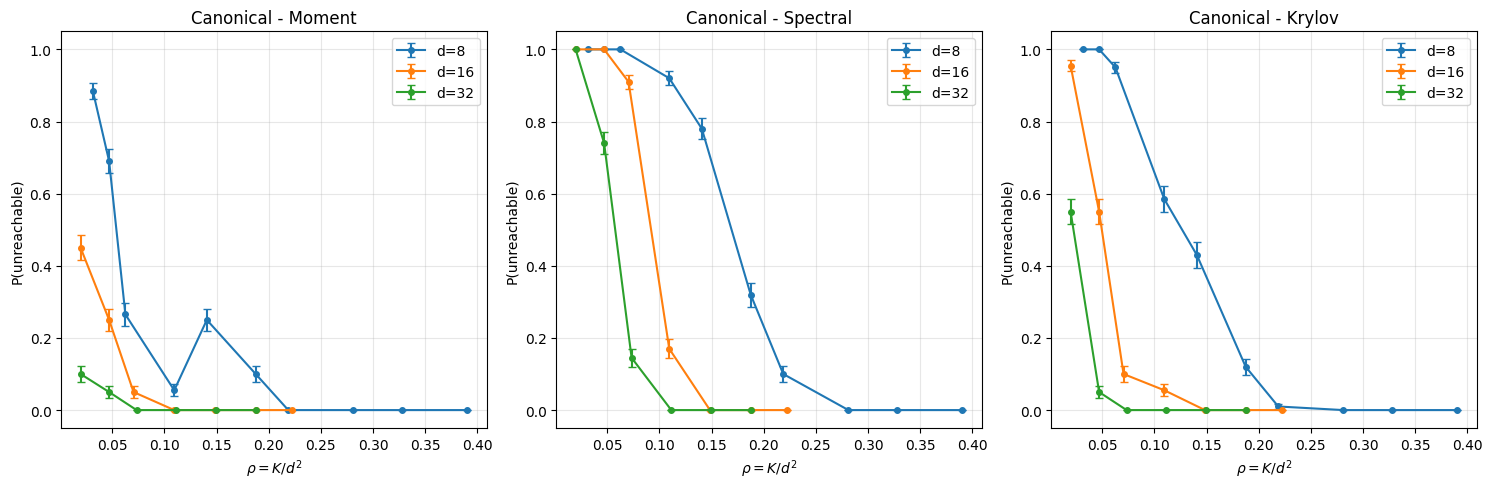

In [4]:
from src.plotting import DIM_COLORS

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, crit in zip(axes, ['moment', 'spectral', 'krylov']):
    for d, df in canonical_results.items():
        if len(df) == 0:
            continue
        color = DIM_COLORS.get(d, None)
        ax.errorbar(df['rho'], df[f'{crit}_P'], yerr=df[f'{crit}_sem'],
                    fmt='o-', color=color, label=f'd={d}', capsize=3, markersize=4)
    ax.set_xlabel(r'$\rho = K/d^2$')
    ax.set_ylabel('P(unreachable)')
    ax.set_title(f'Canonical - {crit.capitalize()}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-0.05, 1.05)
plt.tight_layout()
plt.savefig('../fig/quickstart_canonical.png', dpi=150, bbox_inches='tight')
plt.show()

## Density Sweep: QubitGridModel (~2-3 min)

Same sweep using Pauli operators on qubit lattices.

`sample_submodel(K)` selects K operators from the Pauli basis P_2(G) without replacement,
matching paper Sec. IV.B. Each H_k is a single 1-local or 2-local Pauli operator.

**Note on Krylov at small K:** At K=2-3, the L-BFGS-B optimizer has very few parameters
to optimize over, which can cause minor non-monotonicity in the Krylov curve due to
convergence issues (not physics). With more restarts or trials, these fluctuations smooth out.
By K ~ 5-10, generic Pauli operators span full space and Krylov drops to P=0.
See `krylov_qubitgrid_analysis.ipynb` for a detailed explanation.

In [5]:
qubit_results = {}
lattice_configs = {8: (1, 3), 16: (2, 2), 32: (1, 5)}

for d, (nx, ny) in lattice_configs.items():
    print(f"\nQubitGridModel d={d} ({nx}x{ny} lattice)")
    model = QubitGridModel(dim=d, nx=nx, ny=ny, seed=42)

    config = SweepConfig(n_hamiltonians=20, n_targets=10, tau=0.99,
                         maxiter=50, restarts=3)

    sweep = DensitySweep(model, config)

    # QubitGrid has fewer operators; use actual rho range
    rho_max_actual = model.K / d**2
    K_values = adaptive_K_values(d, rho_c=min(0.10, rho_max_actual / 2),
                                  rho_min=0.02, rho_max=min(0.50, rho_max_actual),
                                  n_total=10, K_max=model.K)

    qubit_results[d] = sweep.run(
        K_values, criteria=['moment', 'spectral', 'krylov'], early_stop_zeros=3)


QubitGridModel d=8 (1x3 lattice)
  K=2/27, rho=0.0312... 

moment=0.50, spectral=1.00, krylov=0.87
  K=3/27, rho=0.0469... 

moment=0.01, spectral=1.00, krylov=0.91
  K=6/27, rho=0.0938... 

moment=0.00, spectral=0.53, krylov=0.26
  K=8/27, rho=0.1250... 

moment=0.00, spectral=0.20, krylov=0.06
  K=11/27, rho=0.1719... 

...

moment=0.00, spectral=0.06, krylov=0.00
  K=28/51, rho=0.0273... 

moment=0.00, spectral=0.04, krylov=0.00
  K=31/51, rho=0.0303... 

moment=0.00, spectral=0.00, krylov=0.00
  K=38/51, rho=0.0371... 

moment=0.00, spectral=0.00, krylov=0.00
  K=44/51, rho=0.0430... 

moment=0.00, spectral=0.00, krylov=0.00
  Early stop: 3 consecutive zeros


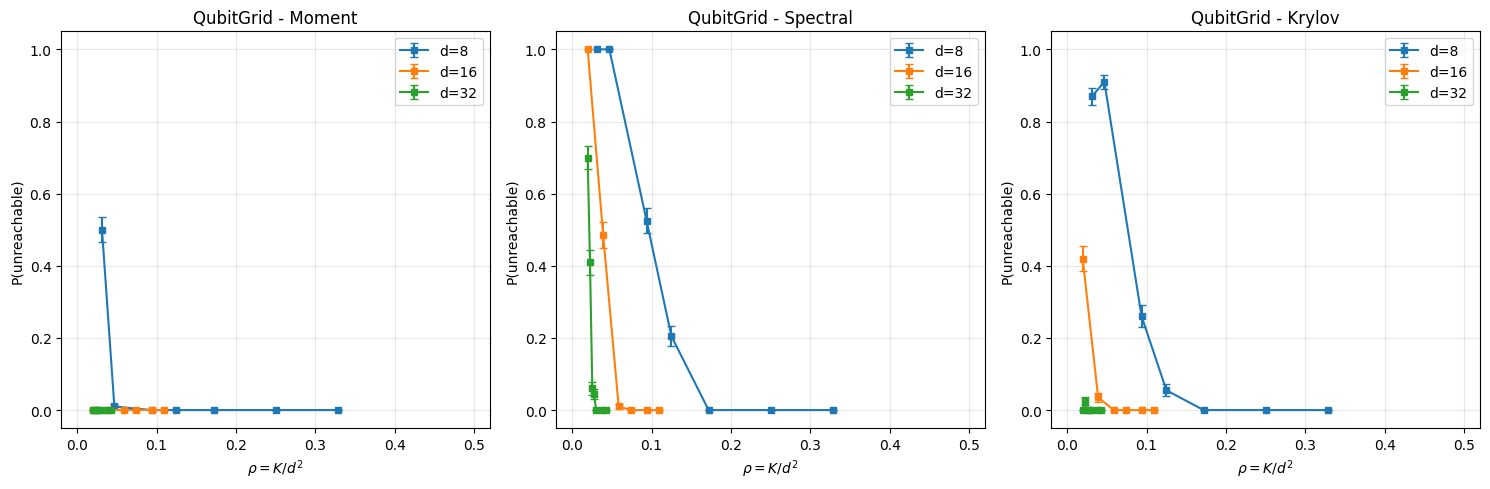

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, crit in zip(axes, ['moment', 'spectral', 'krylov']):
    for d, df in qubit_results.items():
        if len(df) == 0:
            continue
        color = DIM_COLORS.get(d, None)
        ax.errorbar(df['rho'], df[f'{crit}_P'], yerr=df[f'{crit}_sem'],
                    fmt='s-', color=color, label=f'd={d}', capsize=3, markersize=4)
    ax.set_xlabel(r'$\rho = K/d^2$')
    ax.set_ylabel('P(unreachable)')
    ax.set_title(f'QubitGrid - {crit.capitalize()}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlim(-0.02, 0.52)
plt.tight_layout()
plt.savefig('../fig/quickstart_qubitgrid.png', dpi=150, bbox_inches='tight')
plt.show()